In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
pd.set_option('display.max_columns', None)

In [17]:
training_df=pd.read_csv("../Datasets//training_df.csv")
training_df.fillna(0,inplace=True)
training_df.drop(['date','time'],axis=1,inplace=True)
training_df

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,fire
0,10.460000,95.428820,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,1012.03436,3.900000,4.0,0.0,1.0,0.000000,0.057978,7.421590,12.229406,112.833694,137.38599,11.879999,10.760000,13.110001,14.010000,21.910000,0.275,0.318,0.195,0.026,1
1,10.453500,95.428590,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,1011.91230,3.900000,4.0,0.0,1.0,0.000000,0.057956,7.421590,12.229406,112.833694,137.38599,11.879999,10.753500,13.103500,14.003500,21.903500,0.275,0.318,0.195,0.026,1
2,10.414500,95.427210,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,1011.18120,3.900000,4.0,0.0,1.0,0.000000,0.057823,7.421590,12.229406,112.833694,137.38599,11.879999,10.714500,13.064501,13.964500,21.864500,0.275,0.318,0.195,0.026,1
3,9.223500,99.663920,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,1010.78680,2.700000,3.0,0.0,0.0,0.000000,0.003924,5.937272,11.885453,75.963730,125.13428,13.320000,10.423500,12.823500,13.723500,21.923500,0.273,0.324,0.201,0.020,1
4,9.243000,99.663990,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,1011.15370,2.700000,3.0,0.0,0.0,0.000000,0.003929,5.937272,11.885453,75.963730,125.13428,13.320000,10.443000,12.842999,13.743000,21.942999,0.273,0.324,0.201,0.020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113891,28.476500,26.921050,7.6265,26.616827,0.0,0.0,0.0,0.0,1.0,1015.9,827.84717,32.100002,0.0,41.0,25.0,0.590094,2.840295,14.400000,18.440998,233.130020,231.34016,38.160000,41.726498,30.776499,26.726500,18.426498,0.042,0.134,0.192,0.235,0
113892,25.435000,36.749325,9.5850,24.854360,0.0,0.0,0.0,0.0,0.0,1009.1,957.93960,0.000000,0.0,0.0,0.0,0.062706,2.056562,3.259939,8.825508,276.340100,348.23172,17.640000,32.185000,28.734999,23.435000,17.535000,0.135,0.170,0.229,0.293,0
113893,13.914001,82.397710,10.9640,13.423975,0.0,0.0,0.0,0.0,3.0,1012.1,965.82623,94.500000,100.0,0.0,15.0,0.216334,0.280129,5.411986,6.569383,176.186000,170.53775,18.720000,14.164001,13.364000,12.314000,12.314000,0.231,0.314,0.330,0.342,0
113894,7.604000,52.525845,-1.4960,4.411881,0.0,0.0,0.0,0.0,0.0,1017.0,741.41956,0.000000,0.0,0.0,0.0,0.013543,0.496763,5.815978,13.493999,338.198520,313.91916,18.720000,10.654000,14.604001,13.604000,7.954000,0.270,0.296,0.347,0.392,0


In [32]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113896 entries, 0 to 113895
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   temperature_2m                 113896 non-null  float64
 1   relative_humidity_2m           113896 non-null  float64
 2   dew_point_2m                   113896 non-null  float64
 3   apparent_temperature           113896 non-null  float64
 4   precipitation                  113896 non-null  float64
 5   rain                           113896 non-null  float64
 6   snowfall                       113896 non-null  float64
 7   snow_depth                     113896 non-null  float64
 8   weather_code                   113896 non-null  float64
 9   pressure_msl                   113896 non-null  float64
 10  surface_pressure               113896 non-null  float64
 11  cloud_cover                    113896 non-null  float64
 12  cloud_cover_low               

In [18]:
# Remove the target label if necessary
X = training_df.drop(columns=['fire'])  # Ensure only features remain


In [34]:
X

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
0,10.460000,95.428820,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,1012.03436,3.900000,4.0,0.0,1.0,0.000000,0.057978,7.421590,12.229406,112.833694,137.38599,11.879999,10.760000,13.110001,14.010000,21.910000,0.275,0.318,0.195,0.026
1,10.453500,95.428590,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,1011.91230,3.900000,4.0,0.0,1.0,0.000000,0.057956,7.421590,12.229406,112.833694,137.38599,11.879999,10.753500,13.103500,14.003500,21.903500,0.275,0.318,0.195,0.026
2,10.414500,95.427210,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,1011.18120,3.900000,4.0,0.0,1.0,0.000000,0.057823,7.421590,12.229406,112.833694,137.38599,11.879999,10.714500,13.064501,13.964500,21.864500,0.275,0.318,0.195,0.026
3,9.223500,99.663920,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,1010.78680,2.700000,3.0,0.0,0.0,0.000000,0.003924,5.937272,11.885453,75.963730,125.13428,13.320000,10.423500,12.823500,13.723500,21.923500,0.273,0.324,0.201,0.020
4,9.243000,99.663990,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,1011.15370,2.700000,3.0,0.0,0.0,0.000000,0.003929,5.937272,11.885453,75.963730,125.13428,13.320000,10.443000,12.842999,13.743000,21.942999,0.273,0.324,0.201,0.020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113891,28.476500,26.921050,7.6265,26.616827,0.0,0.0,0.0,0.0,1.0,1015.9,827.84717,32.100002,0.0,41.0,25.0,0.590094,2.840295,14.400000,18.440998,233.130020,231.34016,38.160000,41.726498,30.776499,26.726500,18.426498,0.042,0.134,0.192,0.235
113892,25.435000,36.749325,9.5850,24.854360,0.0,0.0,0.0,0.0,0.0,1009.1,957.93960,0.000000,0.0,0.0,0.0,0.062706,2.056562,3.259939,8.825508,276.340100,348.23172,17.640000,32.185000,28.734999,23.435000,17.535000,0.135,0.170,0.229,0.293
113893,13.914001,82.397710,10.9640,13.423975,0.0,0.0,0.0,0.0,3.0,1012.1,965.82623,94.500000,100.0,0.0,15.0,0.216334,0.280129,5.411986,6.569383,176.186000,170.53775,18.720000,14.164001,13.364000,12.314000,12.314000,0.231,0.314,0.330,0.342
113894,7.604000,52.525845,-1.4960,4.411881,0.0,0.0,0.0,0.0,0.0,1017.0,741.41956,0.000000,0.0,0.0,0.0,0.013543,0.496763,5.815978,13.493999,338.198520,313.91916,18.720000,10.654000,14.604001,13.604000,7.954000,0.270,0.296,0.347,0.392


In [19]:
# Normalize the data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [33]:
X_scaled

array([[-1.09912246,  2.26439969,  0.92291804, ...,  2.12036223,
         0.11299086, -2.11652843],
       [-1.09992031,  2.26439028,  0.92207959, ...,  2.12036223,
         0.11299086, -2.11652843],
       [-1.10470739,  2.26433387,  0.91704887, ...,  2.12036223,
         0.11299086, -2.11652843],
       ...,
       [-0.6751588 ,  1.73166437,  1.07822532, ...,  2.06260339,
         1.66709278,  1.18066782],
       [-1.44968419,  0.51044856, -0.52902445, ...,  1.8026886 ,
         1.8627945 ,  1.70237609],
       [ 1.68898441, -0.80969038,  0.61520585, ..., -0.30550911,
        -0.16329392, -0.44706197]], shape=(113896, 30))

In [20]:
# Apply PCA with 2 components
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)


In [21]:
# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)


In [22]:
# Explained variance
explained_variance_2d = sum(pca_2d.explained_variance_ratio_) * 100
explained_variance_3d = sum(pca_3d.explained_variance_ratio_) * 100


In [23]:
# Determine number of components to retain at least 95% variance
pca_full = PCA().fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1


In [24]:
# Get top three eigenvalues
top_eigenvalues = pca_full.explained_variance_[:3]


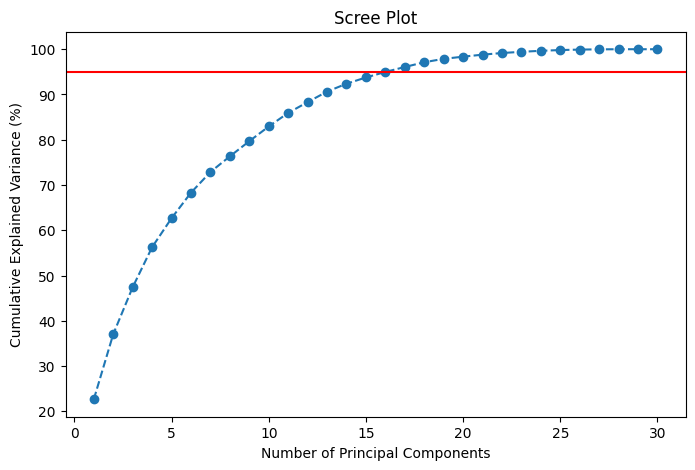

In [25]:
# Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker='o', linestyle='--')
plt.axhline(y=95, color='r', linestyle='-')  # 95% Threshold Line
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Scree Plot')
plt.show()


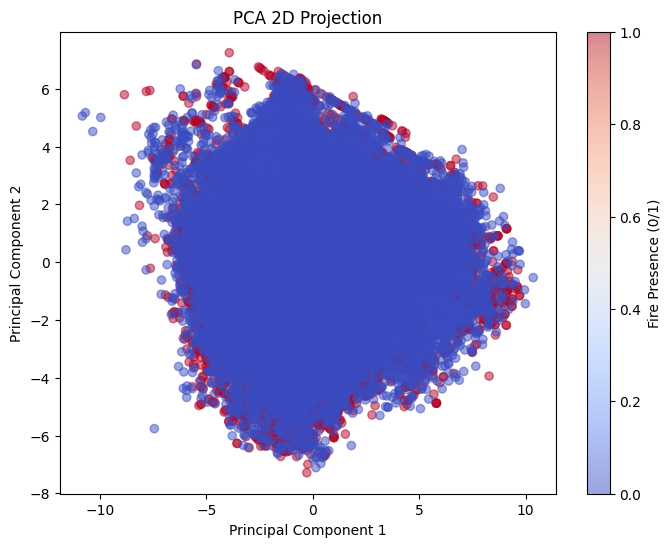

In [27]:
# Visualizing the 2D PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=training_df['fire'], cmap='coolwarm', alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Projection")
plt.colorbar(label="Fire Presence (0/1)")
plt.show()


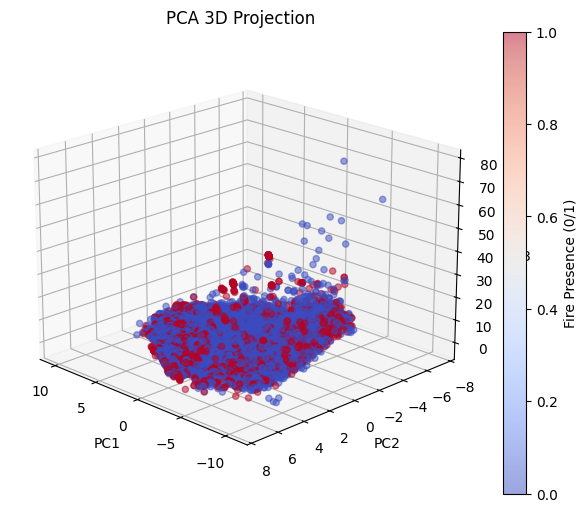

In [29]:
# Visualizing the 3D PCA
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=training_df['fire'], cmap='coolwarm', alpha=0.5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D Projection")
ax.view_init(elev=20, azim=135)  # Adjust angle
fig.colorbar(sc, label="Fire Presence (0/1)")
plt.show()


In [30]:
# Displaying results
print(f"Explained Variance (2D): {explained_variance_2d:.2f}%")
print(f"Explained Variance (3D): {explained_variance_3d:.2f}%")
print(f"Number of components needed for 95% variance: {num_components_95}")
print(f"Top three eigenvalues: {top_eigenvalues}")


Explained Variance (2D): 37.07%
Explained Variance (3D): 47.44%
Number of components needed for 95% variance: 17
Top three eigenvalues: [6.80545976 4.31603153 3.11069461]
